<small>This repository was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), PhD student in AI & DS @ Politecnico di Milano, DEIB, Data Science Lab.</small>
<br><small>Thanks to [Madhura Patil](https://www.kaggle.com/madhuradp8825) for inspiring this notebook.</small>

## Environment Setup

The next cells prepare a local Python environment for this notebook by:

- creating a virtual environment in the current directory (`.venv`)
- activating it
- upgrading `pip`
- installing required packages: `numpy`, `pandas`, `matplotlib`, and `seaborn`

> Use the Linux/macOS commands by default, and the commented alternatives if running on Windows.

In [31]:
""" # Create a virtual environment in the current folder
!python -m venv .venv

# Upgrade pip inside the venv (Linux/macOS)
!source .venv/bin/activate && python -m pip install --upgrade pip

# If you are on Windows, use this instead of the line above:
# !.venv\Scripts\activate && python -m pip install --upgrade pip """

' # Create a virtual environment in the current folder\n!python -m venv .venv\n\n# Upgrade pip inside the venv (Linux/macOS)\n!source .venv/bin/activate && python -m pip install --upgrade pip\n\n# If you are on Windows, use this instead of the line above:\n# !.venv\\Scripts\x07ctivate && python -m pip install --upgrade pip '

In [32]:
""" # Linux/macOS
!source .venv/bin/activate && python -m pip install numpy pandas matplotlib seaborn scikit-learn scipy

# Windows alternative:
# !.venv\Scripts\activate && python -m pip install numpy pandas matplotlib seaborn scikit-learn scipy """

' # Linux/macOS\n!source .venv/bin/activate && python -m pip install numpy pandas matplotlib seaborn scikit-learn scipy\n\n# Windows alternative:\n# !.venv\\Scripts\x07ctivate && python -m pip install numpy pandas matplotlib seaborn scikit-learn scipy '

## Library Imports and CSV Loading

In this section, we import the core libraries used for data analysis and then load the `Synthetic Stroke Prediction Dataset` from a CSV file into a pandas DataFrame.

- `pandas`: used to read and manipulate tabular data
- `numpy`: useful for numerical operations
- `matplotlib`: used for creating visualizations
- `seaborn`: used for statistical data visualization

After loading, we will preview the first rows to verify that the dataset was read correctly.

In [33]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt # plotting library
import seaborn as sns # statistical data visualization

# Input data files are available in this directory
import os
for dirname, _, filenames in os.walk('./datasets/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./datasets/california-housing.csv
./datasets/titanic_seaborn.csv
./datasets/healthcare-dataset-stroke-data.csv
./datasets/tips_seaborn.csv
./datasets/outlier_detection_dataset.csv
./datasets/synthetic_stroke_data.csv
./datasets/flights_seaborn.csv
./datasets/iris_seaborn.csv


In [34]:
# Load the dataset
data = pd.read_csv('./datasets/healthcare-dataset-stroke-data.csv')

## 1. Dataset Overview

In this section, we will perform a quick structural and statistical check of the dataset to understand its size, content quality, and key numeric relationships.

Specifically, we will inspect:

- **Dataset size** using `data.shape`
- **First look at the data** using `data.head()` and `data.sample(...)`
- **Column data types and non-null counts** using `data.info()`
- **Missing values per column** using `data.isnull().sum()`
- **Statistical summary of numeric features** using `data.describe()`
- **Duplicate rows** using `data.duplicated().sum()`
- **Correlation between numeric columns** using `data.corr(numeric_only=True)`

This gives a solid baseline before cleaning, feature engineering, and modeling.

### 1.1 Dataset Size

We start by checking **how big the dataset is** using:

- `data.shape` *(or `df.shape` if your DataFrame is named `df`)*

In [35]:
print("Dataset size (rows, columns):")
data.shape # Check the number of rows and columns in the dataset

Dataset size (rows, columns):


(5110, 12)

### 1.2 First Look at the Data

We now inspect how the dataset looks using:

- `data.head()` to view the first rows
- `data.sample(5, random_state=42)` to view a random sample

In [36]:
# Preview the first rows
print("First 5 rows:")
data.head()

First 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [37]:
# Preview a random sample of rows
print("\nRandom sample (5 rows):")
data.sample(5, random_state=42)


Random sample (5 rows):


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4688,40041,Male,31.0,0,0,No,Self-employed,Rural,64.85,23.0,Unknown,0
4478,55244,Male,40.0,0,0,Yes,Self-employed,Rural,65.29,28.3,never smoked,0
3849,70992,Female,8.0,0,0,No,children,Urban,74.42,22.5,Unknown,0
4355,38207,Female,79.0,1,0,Yes,Self-employed,Rural,76.64,19.5,never smoked,0
3826,8541,Female,75.0,0,0,Yes,Govt_job,Rural,94.77,27.2,never smoked,0


### 1.3 Data Types

We now inspect the data types of each column with the non-null count using:

- `data.info()` to view column data types and non-null counts

The attributes in our dataset can be categorized into two main types:
- **Numerical Attributes**: These are attributes that represent quantitative measurements. They can be further categorized into:
  - **Continuous**: Can take any value within a range (e.g., age, blood pressure).
  - **Discrete**: Can take specific values (e.g., number of children, count of hospital visits).
- **Categorical Attributes**: These are attributes that represent qualitative data. They can be further categorized into:
  - **Nominal**: Categories without a natural order (e.g., gender, blood type).
  - **Ordinal**: Categories with a natural order (e.g., severity of stroke: mild, moderate, severe).

In [38]:
print("Dataset info:")
data.info()

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


### 1.4 Missing Values

We now inspect which columns have missing values and how many using:

- `data.isnull().sum()` to count missing values per column

In [39]:
print("Missing values per column:")
data.isnull().sum()

Missing values per column:


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### 1.5 Statistical Summary

We now inspect the statistical properties of numeric columns using:

- `data.describe()` to view count, mean, standard deviation, min, quartiles, and max values

In [40]:
print("Statistical Summary of Numeric Features:")
data.describe()

Statistical Summary of Numeric Features:


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### 1.6 Duplicate Rows

Now we check whether the dataset contains repeated records using:

- `data.duplicated().sum()` to count how many rows are exact duplicates

In [41]:
print("Duplicate rows:")
data.duplicated().sum()

Duplicate rows:


0

In [42]:
# Simulate a duplicated row by appending a copy of the first row to the dataset
data_with_duplicates = pd.concat([data, data.iloc[[0]]], ignore_index=True)

print("Dataset shape after adding duplicate:")
print(data_with_duplicates.shape)

print("Duplicate rows count:")
print(data_with_duplicates.duplicated().sum())

Dataset shape after adding duplicate:
(5111, 12)
Duplicate rows count:
1


### 1.7 Correlation Between Columns

Finally, we examine **linear relationships between numeric variables** using a correlation matrix.

- Use `df.corr(numeric_only=True)` to compute pairwise Pearson correlations.
- Correlation values range from **-1 to 1**:
    - **+1**: strong positive relationship  
    - **0**: no linear relationship  
    - **-1**: strong negative relationship

This step helps identify which numeric features move together (or in opposite directions), and supports feature selection and interpretation before modeling.

In [43]:
# Use the existing DataFrame as df
df = data

# Try correlation on all columns (numeric columns will be used)
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

                         id       age  hypertension  heart_disease  \
id                 1.000000  0.003538      0.003550      -0.001296   
age                0.003538  1.000000      0.276398       0.263796   
hypertension       0.003550  0.276398      1.000000       0.108306   
heart_disease     -0.001296  0.263796      0.108306       1.000000   
avg_glucose_level  0.001092  0.238171      0.174474       0.161857   
bmi                0.003084  0.333398      0.167811       0.041357   
stroke             0.006388  0.245257      0.127904       0.134914   

                   avg_glucose_level       bmi    stroke  
id                          0.001092  0.003084  0.006388  
age                         0.238171  0.333398  0.245257  
hypertension                0.174474  0.167811  0.127904  
heart_disease               0.161857  0.041357  0.134914  
avg_glucose_level           1.000000  0.175502  0.131945  
bmi                         0.175502  1.000000  0.042374  
stroke                    

We now visualize the **correlation between numeric columns** using a heatmap. This provides a quick visual overview of which features are strongly related:

- `sns.heatmap()` creates a color-coded matrix where:
    - **Warm colors (red)** indicate positive correlations
    - **Cool colors (blue)** indicate negative correlations
    - **Light colors (white)** indicate weak or no correlation
    - **Annotations** show the exact correlation values (ranging from -1 to 1)

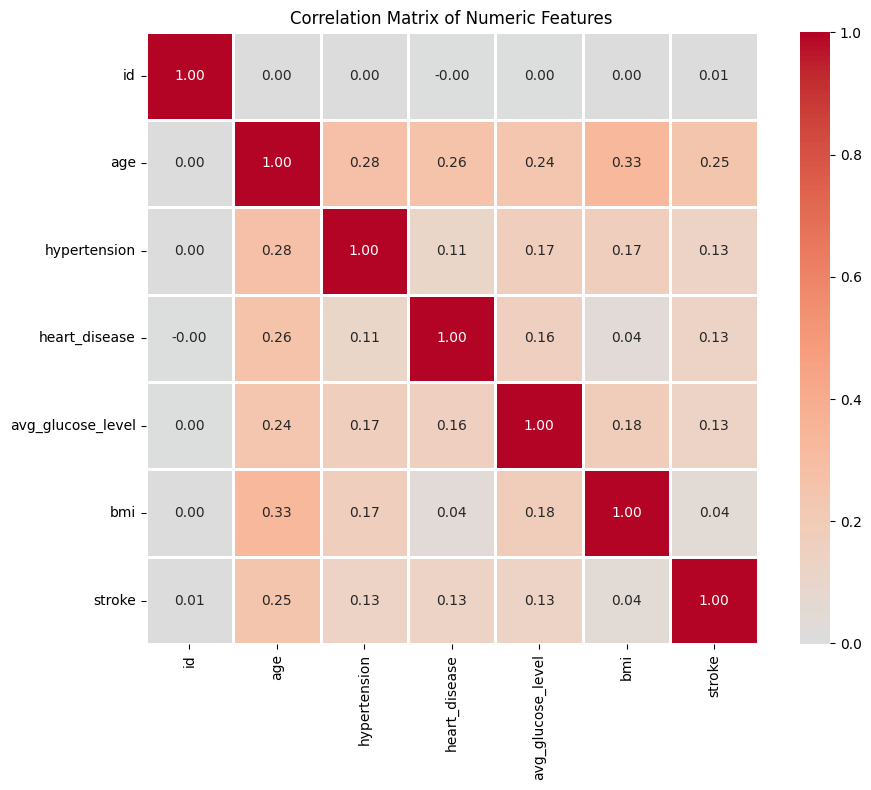

In [44]:
# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=1)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()